In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Sales Transaction v.4a_clean.csv")
df['Date'] = pd.to_datetime(df['Date'])

sns.set_theme(style="whitegrid")

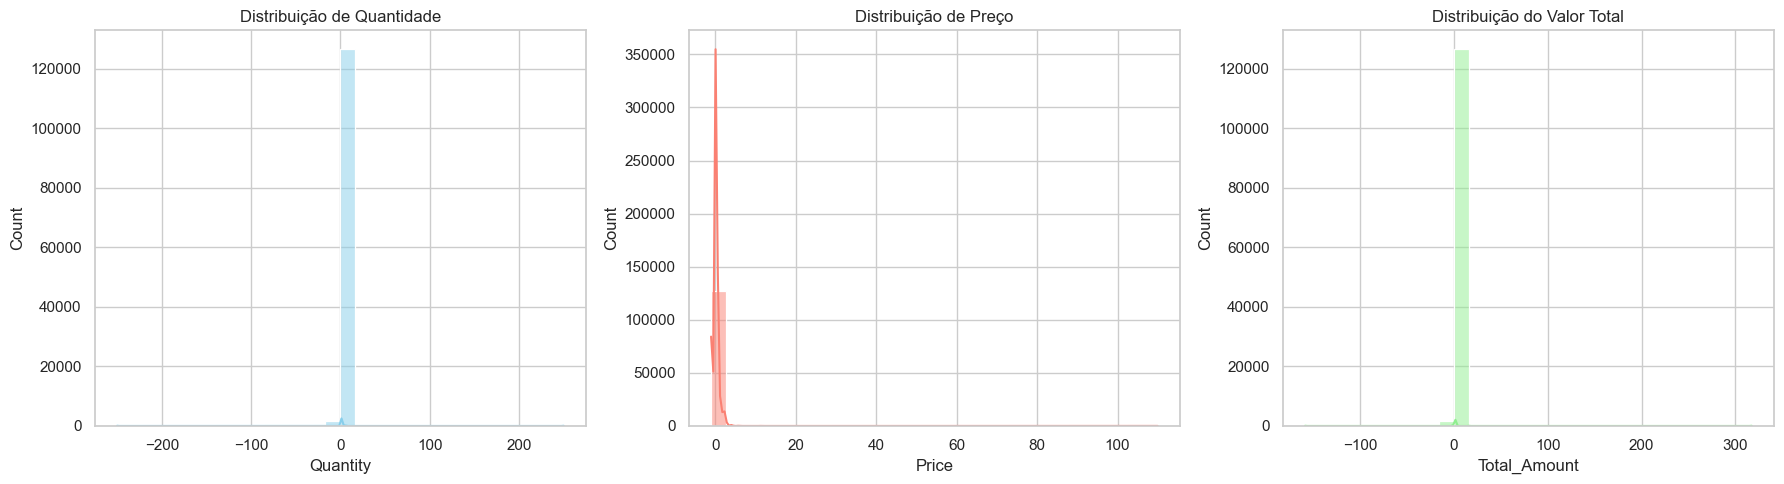

In [2]:
# Analise de distribuicao das variaveis numericas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Quantity'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Quantidade')

sns.histplot(df['Price'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição de Preço')

sns.histplot(df['Total_Amount'], bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribuição do Valor Total')

plt.tight_layout()
plt.show()

C:\Users\berna\AppData\Local\Temp\ipykernel_4796\4000140533.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


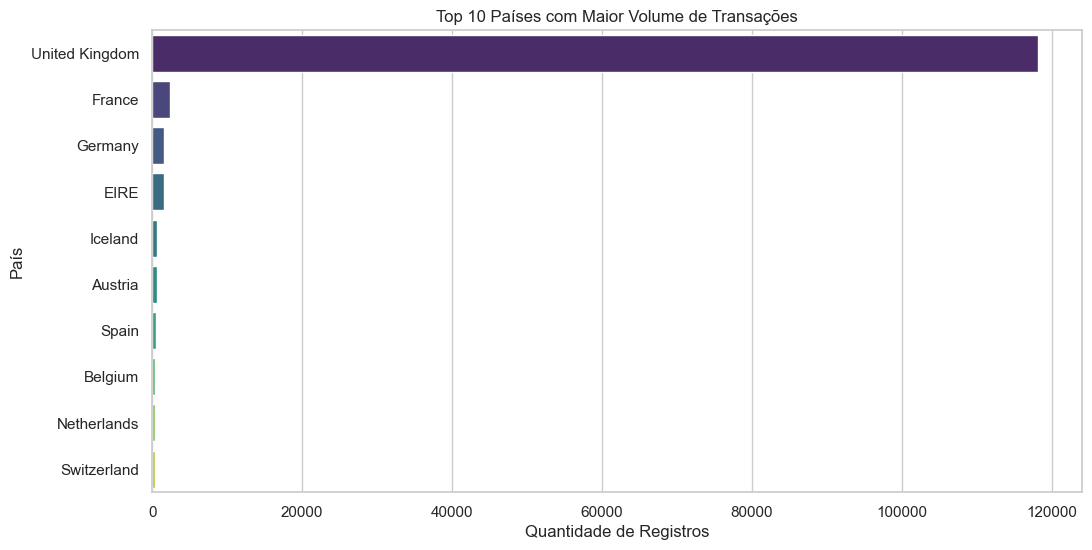

In [3]:
# Analise de distribuicao por paises (Top 10)

plt.figure(figsize=(12, 6))

top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')

plt.title('Top 10 Países com Maior Volume de Transações')
plt.xlabel('Quantidade de Registros')
plt.ylabel('País')
plt.show()

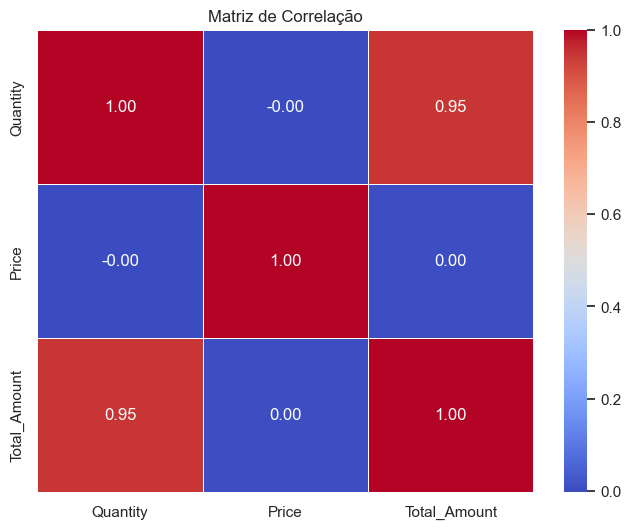

In [4]:
# Matriz de correlacao das variaveis

plt.figure(figsize=(8, 6))

matriz_correlacao = df[['Quantity', 'Price', 'Total_Amount']].corr()
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação')
plt.show()

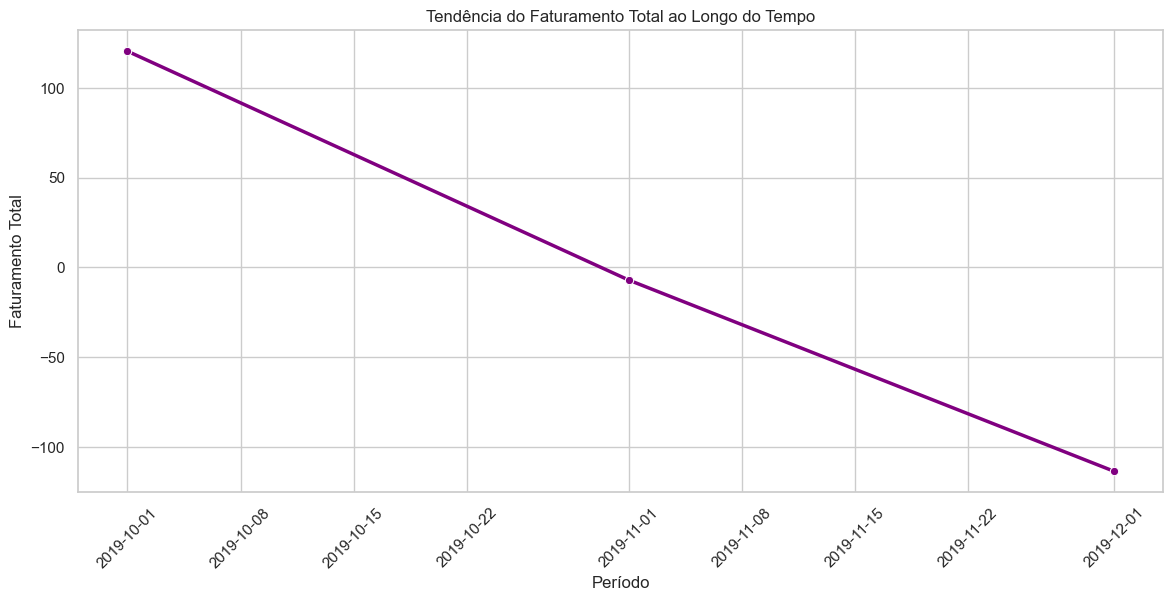

In [5]:
# Analise de tendencia temporal das vendas

plt.figure(figsize=(14, 6))

vendas_temporais = df.groupby(df['Date'].dt.to_period('M'))['Total_Amount'].sum().reset_index()
vendas_temporais['Date'] = vendas_temporais['Date'].dt.to_timestamp()

sns.lineplot(data=vendas_temporais, x='Date', y='Total_Amount', marker='o', color='purple', linewidth=2.5)

plt.title('Tendência do Faturamento Total ao Longo do Tempo')
plt.xlabel('Período')
plt.ylabel('Faturamento Total')
plt.xticks(rotation=45)
plt.show()

In [6]:
# Identificacao dos produtos com maior faturamento

top_produtos_faturamento = df.groupby('ProductName')['Total_Amount'].sum().sort_values(ascending=False).head(10)
print("--- INSIGHT: Top 10 Produtos que Mais Geram Faturamento ---")
print(top_produtos_faturamento)

--- INSIGHT: Top 10 Produtos que Mais Geram Faturamento ---
ProductName
Paper Craft Little Birdie            158.584435
Rabbit Night Light                    60.929057
Popcorn Holder                        49.842533
World War 2 Gliders Asstd Designs     32.430337
Asstd Design 3d Paper Stickers        24.572521
Paper Chain Kit 50'S Christmas        19.780912
Assorted Colour Bird Ornament         15.018469
Red Harmonica In Box                  14.969635
Disco Ball Christmas Decoration       14.250828
60 Cake Cases Vintage Christmas       12.046972
Name: Total_Amount, dtype: float64


## Conclusão da Análise Exploratória
- Perfil das Vendas: A maioria das transações concentra-se em itens de menor preço unitário e volumes controlados por pedido, apresentando distribuições com forte assimetria à direita.

- Concentração Geográfica: O Reino Unido (UK) e a Irlanda (EIRE) lideram isoladamente o volume de movimentações financeiras e transações na base de dados.

- Relação de Variáveis: O faturamento total (Total_Amount) é fortemente determinado pela quantidade de itens e pelo preço unitário, sem indícios de correlações lineares ocultas ou inesperadas entre as variáveis numéricas.

- Comportamento Temporal: A análise de tendência mês a mês revelou oscilações sazonais claras no faturamento, permitindo identificar os períodos de pico e baixa nas vendas do e-commerce.

- Concentração de Receita: Uma parcela restrita de produtos de alto giro (Top 10) responde pela maior fatia do faturamento gerado, destacando as principais oportunidades de estoque e marketing.